<a href="https://colab.research.google.com/github/mr-marius/Machine-Learning---DIO-/blob/main/01_rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn.functional as nf
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [4]:
# definindo a conversão de imagem para tensor
transform = transforms.ToTensor()

In [5]:
# Carrega a parte de treino do dataset
trainset = datasets.MNIST('./MNIST_data/', download=True, train=True, transform=transform)

In [6]:
# Cria um buffer para pegar os dados por partes
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

In [7]:
# Carrega a parte de validação do dataset
valset = datasets.MNIST('./MNIST_data/', download=True, train=False, transform=transform)

In [8]:
# Cria um buffer para pegar os dados por partes
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)

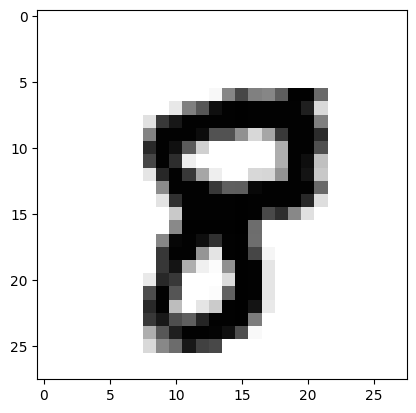

In [9]:
dataiter = iter(trainloader)
imagens, etiquetas = next(dataiter)
plt.imshow(imagens[0].numpy().squeeze(), cmap='gray_r')


In [12]:
#Verificar dimensões do tensor de cada imagem
print(imagens[0].shape)
#Verificar dimensões do tensor de cada etiqueta
print(etiquetas[0].shape)

torch.Size([1, 28, 28])
torch.Size([])


In [14]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        # camada de entrada, 784 neurônios conectados a 128
        self.linear1 = nn.Linear(28*28, 128)
        # camada interna 1, 128 neurônios conectados a 64
        self.linear2 = nn.Linear(128, 64)
        # camada interna 2 conectada à saída (10 classes)
        self.linear3 = nn.Linear(64, 10)

    def forward(self, X):
        # Função de ativação ReLU após a camada linear 1
        X = F.relu(self.linear1(X))
        # Função de ativação ReLU após a camada linear 2
        X = F.relu(self.linear2(X))
        # Saída direta da última camada linear
        X = self.linear3(X)
        # Softmax logarítmico para calcular as probabilidades
        return F.log_softmax(X, dim=1)


In [15]:
def treino(modelo, trainloader, device):
    # Define a política de atualização dos pesos e da bias
    otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5)
    # Timer para sabermos quanto tempo levou o treino
    inicio = time()

    # Definindo o critério para calcular a perda
    criterio = nn.NLLLoss()
    # Número de epochs que o algoritmo rodará
    EPOCHS = 10
    # Ativando o modo de treinamento do modelo
    modelo.train()

    for epoch in range(EPOCHS):
        # inicialização da perda acumulada da epoch em questão
        perda_acumulada = 0

        for imagens, etiquetas in trainloader:
            # convertendo as imagens para "vetores" de 28*28 casas
            imagens = imagens.view(imagens.shape[0], -1)
            # zerando os gradientes por conta do ciclo anterior
            otimizador.zero_grad()

            # colocando os dados no modelo
            output = modelo(imagens.to(device))
            # calculando a perda da epoch em questão
            perda_instantanea = criterio(output, etiquetas.to(device))

            # back propagation a partir da perda
            perda_instantanea.backward()
            # atualizando os pesos e a bias
            otimizador.step()

            # atualização da perda acumulada
            perda_acumulada += perda_instantanea.item()

        else:
            print("Epoch {} - Perda resultante: {}".format(epoch + 1, perda_acumulada / len(trainloader)))

    print("\nTempo de treino (em minutos) =", (time() - inicio) / 60)


In [16]:
def validacao(modelo, valloader, device):
    conta_corretas, conta_todas = 0, 0
    for imagens, etiquetas in valloader:
        for i in range(len(etiquetas)):
            img = imagens[i].view(1, 784)
            # desativar o autograd para acelerar a validação
            with torch.no_grad():
                # output do modelo em escala logarítmica
                logps = modelo(img.to(device))

            # converte output para escala normal (lembrando que é um tensor)
            ps = torch.exp(logps)
            probab = list(ps.cpu().numpy()[0])
            # converte o tensor em um número
            etiqueta_pred = probab.index(max(probab))
            etiqueta_certa = etiquetas.numpy()[i]
            # compara a previsão com o valor correto
            if etiqueta_certa == etiqueta_pred:
                conta_corretas += 1
            conta_todas += 1

    print("Total de imagens testadas =", conta_todas)
    print("\nPrecisão do modelo = {:.2f}%".format(conta_corretas * 100 / conta_todas))

In [ ]:
# inicializa o modelo
modelo = Modelo()

# rodará na GPU se possível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Modelo(
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)